In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS = Path('../outputs/dpf/hmc')

In [2]:
pip install numpy 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
def load_samples(model, method):
    """Load post-burnin samples from trace.csv. Returns DataFrame or None."""
    path = OUTPUTS / model / method / 'trace.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    return df[df['phase'] == 'sample'].reset_index(drop=True)


def plot_model(model, methods, params, true_vals, method_labels=None):
    if method_labels is None:
        method_labels = {m: m for m in methods}

    data = {m: load_samples(model, m) for m in methods}
    available = [m for m in methods if data[m] is not None]

    n_params = len(params)
    n_methods = len(available)

    fig, axes = plt.subplots(
        n_params, n_methods,
        figsize=(3.5 * n_methods, 3.0 * n_params),
        squeeze=False
    )
    fig.suptitle(model.replace('_', ' ').title(), fontsize=14, fontweight='bold', y=1.01)

    for col, method in enumerate(available):
        df = data[method]
        axes[0, col].set_title(method_labels[method], fontsize=11)

        for row, (param, true_val) in enumerate(zip(params, true_vals)):
            ax = axes[row, col]

            if param not in df.columns:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
                ax.set_yticks([])
                continue

            samples = df[param].values
            ax.hist(samples, bins="auto", color='steelblue', edgecolor='white',
                    linewidth=0.4, density=True)
            ax.axvline(true_val, color='black', linewidth=1.8)

            if col == 0:
                ax.set_ylabel(param, fontsize=10)
            ax.set_xlabel('value', fontsize=8)
            ax.tick_params(labelsize=8)
            ax.set_yticks([])
            ax.text(0.97, 0.95, f'n={len(samples)}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=7, color='gray')

    plt.tight_layout()
    plt.show()
    return fig

## Linear Gaussian
True: `obs_noise_std = 1.0`

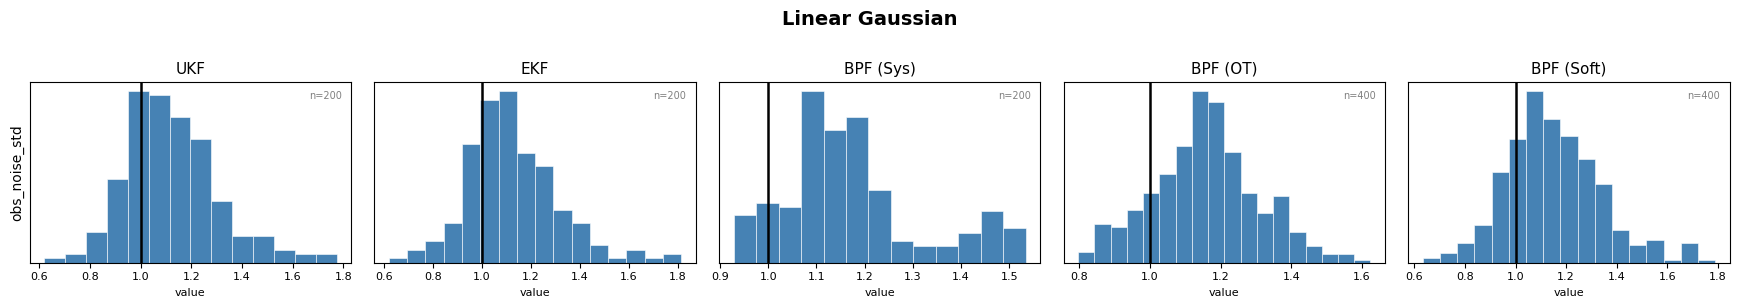

In [8]:
fig_lg = plot_model(
    model='linear_gaussian',
    methods=['ukf', 'ekf', 'bpf_sys', 'bpf_ot', 'bpf_soft'],
    params=['obs_noise_std'],
    true_vals=[1.0],
    method_labels={'ukf': 'UKF', 'ekf': 'EKF',
                   'bpf_sys': 'BPF (Sys)', 'bpf_ot': 'BPF (OT)', 'bpf_soft': 'BPF (Soft)'}
)

## Cubic Sensor
True: `sigma_V = 1.0`, `sigma_W = 1.0`

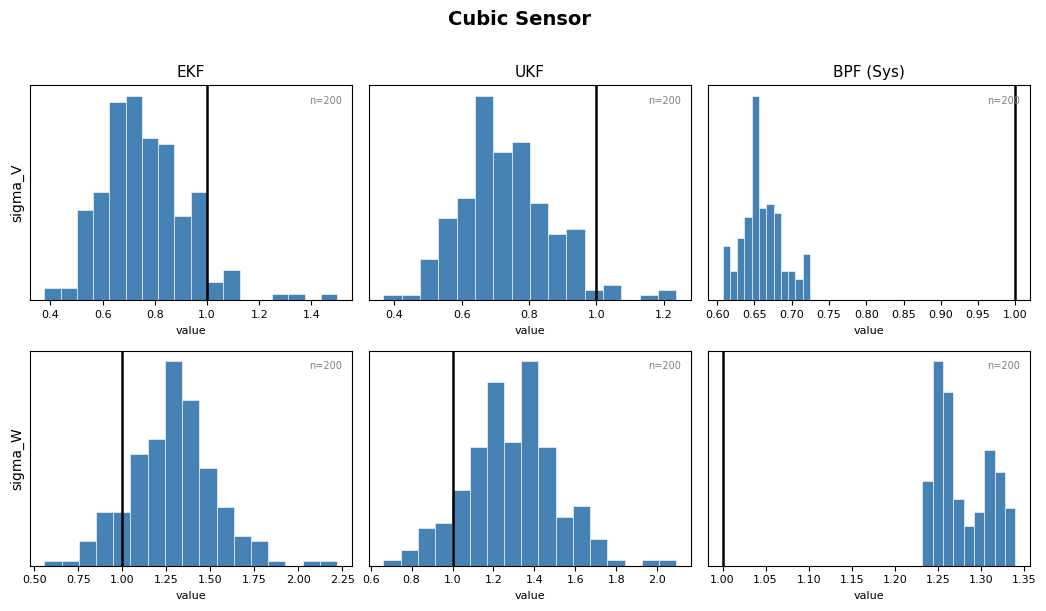

In [55]:
fig_cs = plot_model(
    model='cubic_sensor',
    methods=['ekf', 'ukf', 'bpf_sys', 'bpf_ot', 'bpf_soft'],
    params=['sigma_V', 'sigma_W'],
    true_vals=[1.0, 1.0],
    method_labels={'ekf': 'EKF', 'ukf': 'UKF',
                   'bpf_sys': 'BPF (Sys)', 'bpf_ot': 'BPF (OT)', 'bpf_soft': 'BPF (Soft)'}
)

## Stochastic Volatility
True: `alpha = 0.91`, `sigma = 1.0`, `beta = 0.5`

## Save figures to report/

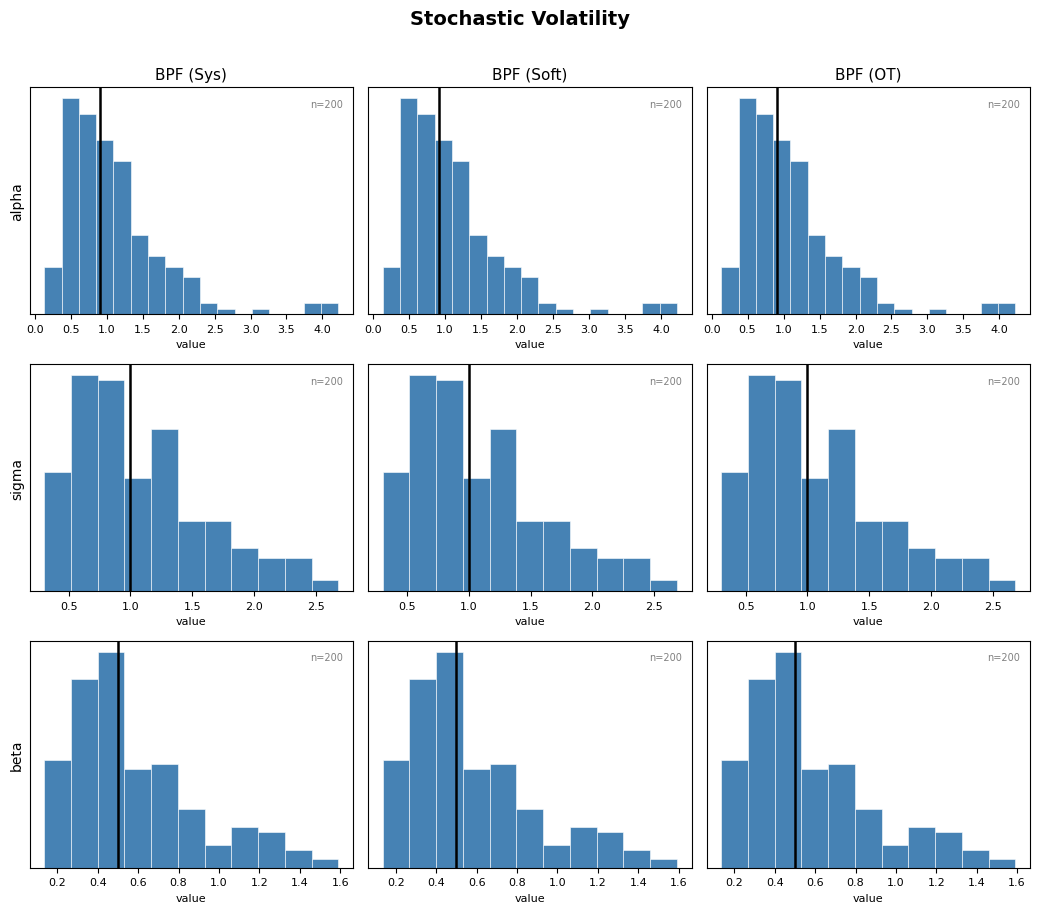

In [56]:
fig_sv = plot_model(
    model='stochastic_volatility',
    methods=['bpf_sys', 'bpf_soft', 'bpf_ot'],
    params=['alpha', 'sigma', 'beta'],
    true_vals=[0.91, 1.0, 0.5],
    method_labels={'bpf_sys': 'BPF (Sys)', 'bpf_soft': 'BPF (Soft)', 'bpf_ot': 'BPF (OT)'}
)

In [57]:
REPORT = Path('../../report')

fig_lg.savefig(REPORT / 'hmc_linear_gaussian.pdf', bbox_inches='tight')
fig_cs.savefig(REPORT / 'hmc_cubic_sensor.pdf', bbox_inches='tight')
fig_sv.savefig(REPORT / 'hmc_stochastic_volatility.pdf', bbox_inches='tight')
print("Saved to report/")

Saved to report/


## EKF across models
Linear Gaussian (`obs_noise_std=1.0`), Cubic Sensor (`sigma_V=1.0, sigma_W=1.0`), Range Bearing (`sigma_range=0.1, sigma_bearing=0.1`)

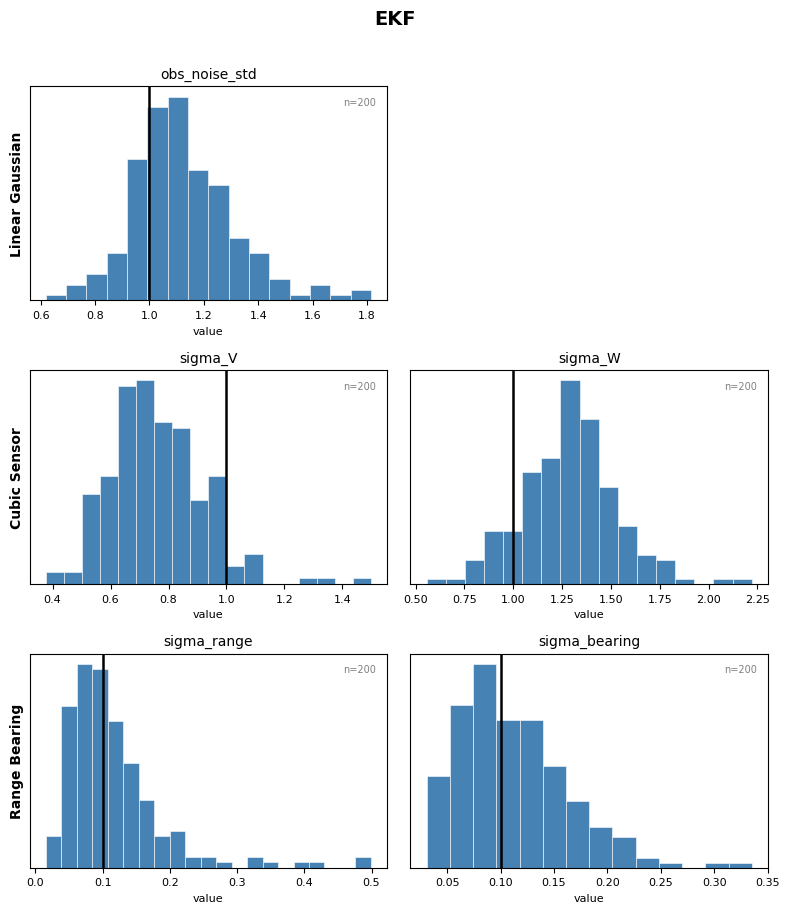

In [58]:
def plot_method_across_models(method, method_label, models_info):
    """Plot a single method across multiple models.
    
    Rows = models, columns = parameters (padded to max params across models).
    """
    n_rows = len(models_info)
    n_cols = max(len(m['params']) for m in models_info)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.0 * n_cols, 3.0 * n_rows),
        squeeze=False
    )
    fig.suptitle(method_label, fontsize=14, fontweight='bold', y=1.01)

    for row, mi in enumerate(models_info):
        df = load_samples(mi['model'], method)
        axes[row, 0].set_ylabel(mi['title'], fontsize=10, fontweight='bold')

        for col in range(n_cols):
            ax = axes[row, col]
            if col >= len(mi['params']):
                ax.axis('off')
                continue

            param = mi['params'][col]
            true_val = mi['true_vals'][col]
            ax.set_title(param, fontsize=10)

            if df is None or param not in df.columns:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
                ax.set_yticks([])
            else:
                samples = df[param].values
                ax.hist(samples, bins='auto', color='steelblue', edgecolor='white',
                        linewidth=0.4, density=True)
                ax.axvline(true_val, color='black', linewidth=1.8)
                ax.text(0.97, 0.95, f'n={len(samples)}', transform=ax.transAxes,
                        ha='right', va='top', fontsize=7, color='gray')

            ax.set_xlabel('value', fontsize=8)
            ax.tick_params(labelsize=8)
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()
    return fig


MODELS_INFO = [
    {'model': 'linear_gaussian', 'params': ['obs_noise_std'], 'true_vals': [1.0],
     'title': 'Linear Gaussian'},
    {'model': 'cubic_sensor', 'params': ['sigma_V', 'sigma_W'], 'true_vals': [1.0, 1.0],
     'title': 'Cubic Sensor'},
    {'model': 'range_bearing', 'params': ['sigma_range', 'sigma_bearing'], 'true_vals': [0.1, 0.1],
     'title': 'Range Bearing'},
]

fig_ekf = plot_method_across_models('ekf', 'EKF', MODELS_INFO)

## UKF across models
Linear Gaussian (`obs_noise_std=1.0`), Cubic Sensor (`sigma_V=1.0, sigma_W=1.0`), Range Bearing (`sigma_range=0.1, sigma_bearing=0.1`)

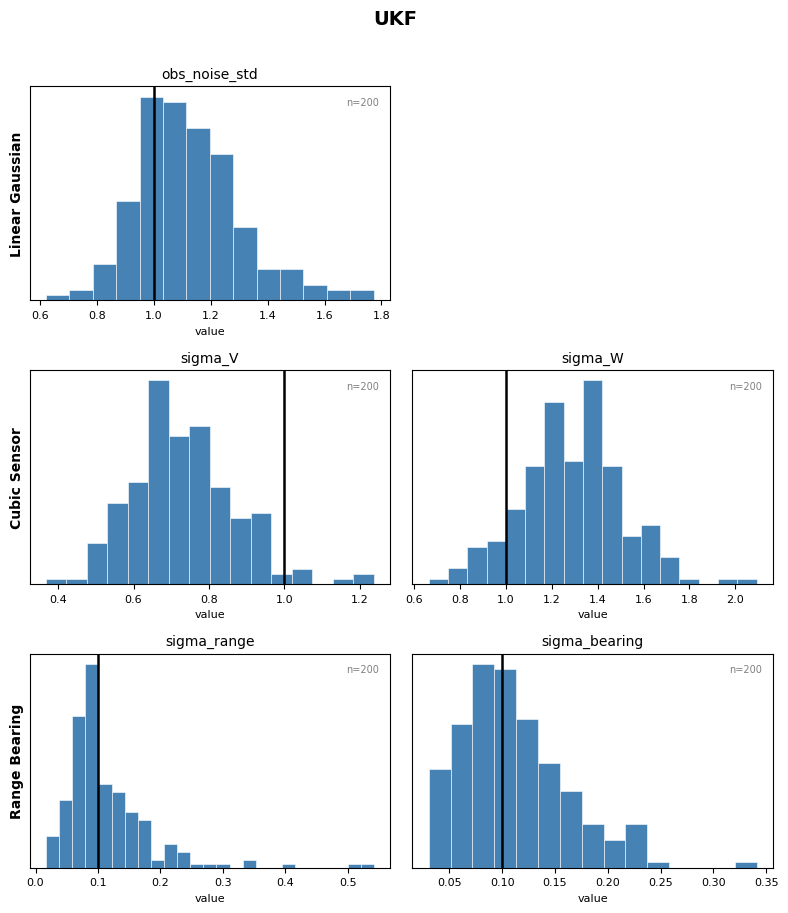

In [59]:
fig_ukf = plot_method_across_models('ukf', 'UKF', MODELS_INFO)

In [60]:
REPORT = Path('../../report')
fig_ekf.savefig(REPORT / 'hmc_ekf.pdf', bbox_inches='tight')
fig_ukf.savefig(REPORT / 'hmc_ukf.pdf', bbox_inches='tight')
print("Saved hmc_ekf.pdf and hmc_ukf.pdf to report/")

Saved hmc_ekf.pdf and hmc_ukf.pdf to report/


## BPF (Systematic) across models

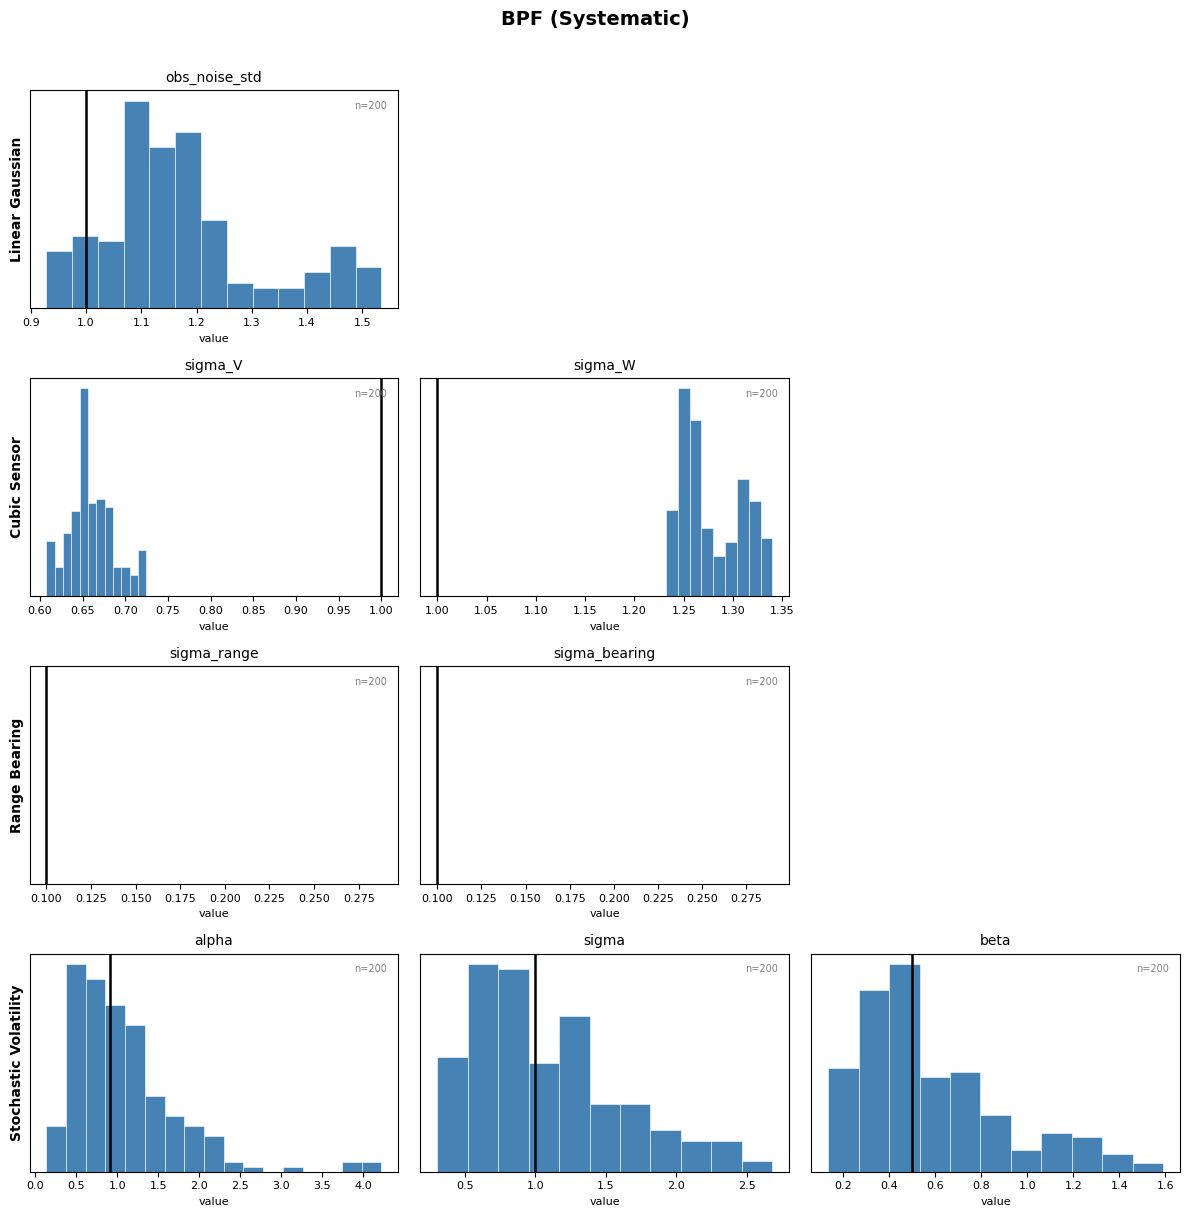

In [ ]:
MODELS_INFO_ALL = [
    {'model': 'linear_gaussian', 'params': ['obs_noise_std'], 'true_vals': [1.0],
     'title': 'Linear Gaussian'},
    {'model': 'cubic_sensor', 'params': ['sigma_V', 'sigma_W'], 'true_vals': [1.0, 1.0],
     'title': 'Cubic Sensor'},
    {'model': 'stochastic_volatility', 'params': ['alpha', 'sigma', 'beta'], 'true_vals': [0.91, 1.0, 0.5],
     'title': 'Stochastic Volatility'},
]

fig_bpf_sys = plot_method_across_models('bpf_sys', 'BPF (Systematic)', MODELS_INFO_ALL)

In [62]:
fig_bpf_sys.savefig(Path('../../report') / 'hmc_bpf_sys.pdf', bbox_inches='tight')
print("Saved hmc_bpf_sys.pdf to report/")

Saved hmc_bpf_sys.pdf to report/


## BPF (Soft Resampling) across models

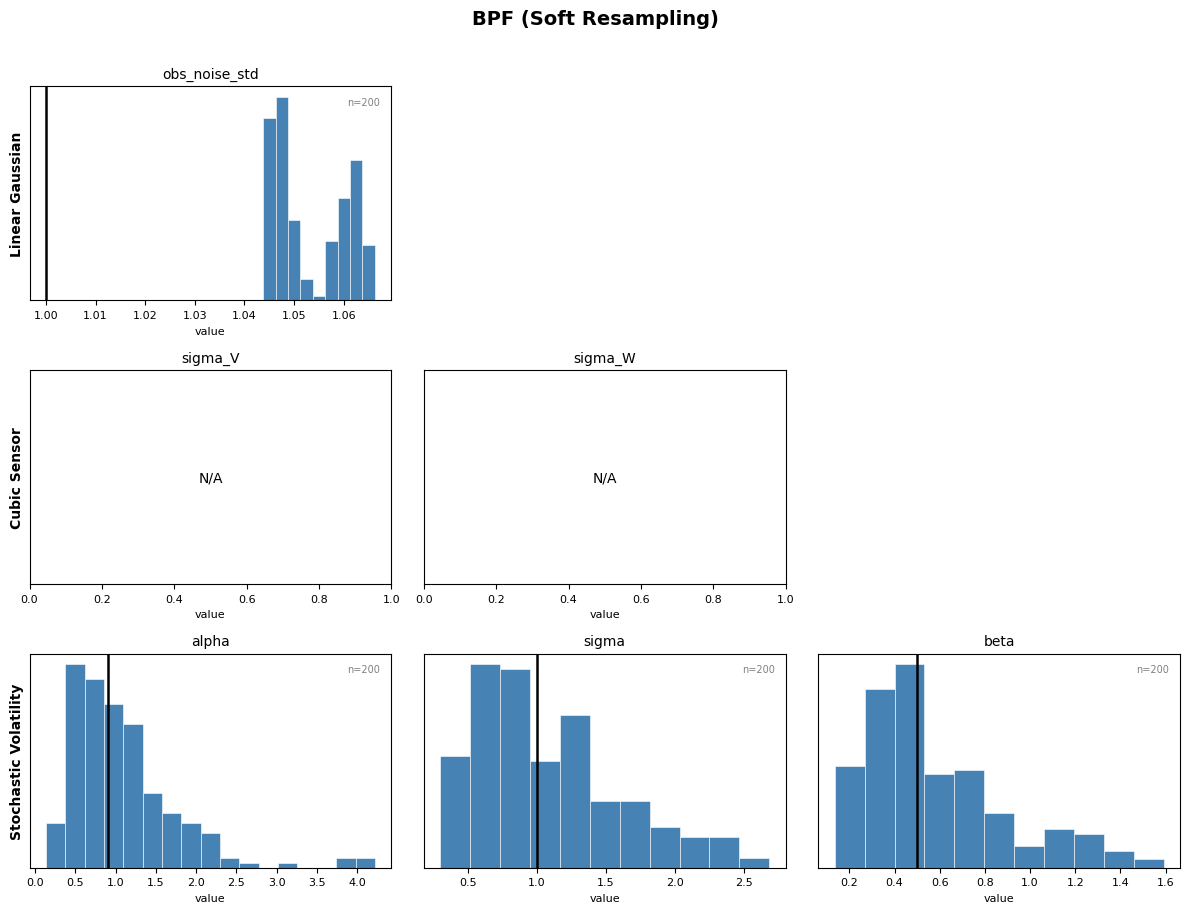

In [65]:
fig_bpf_soft = plot_method_across_models('bpf_soft', 'BPF (Soft Resampling)', MODELS_INFO_ALL)

## BPF (OT Resampling) across models

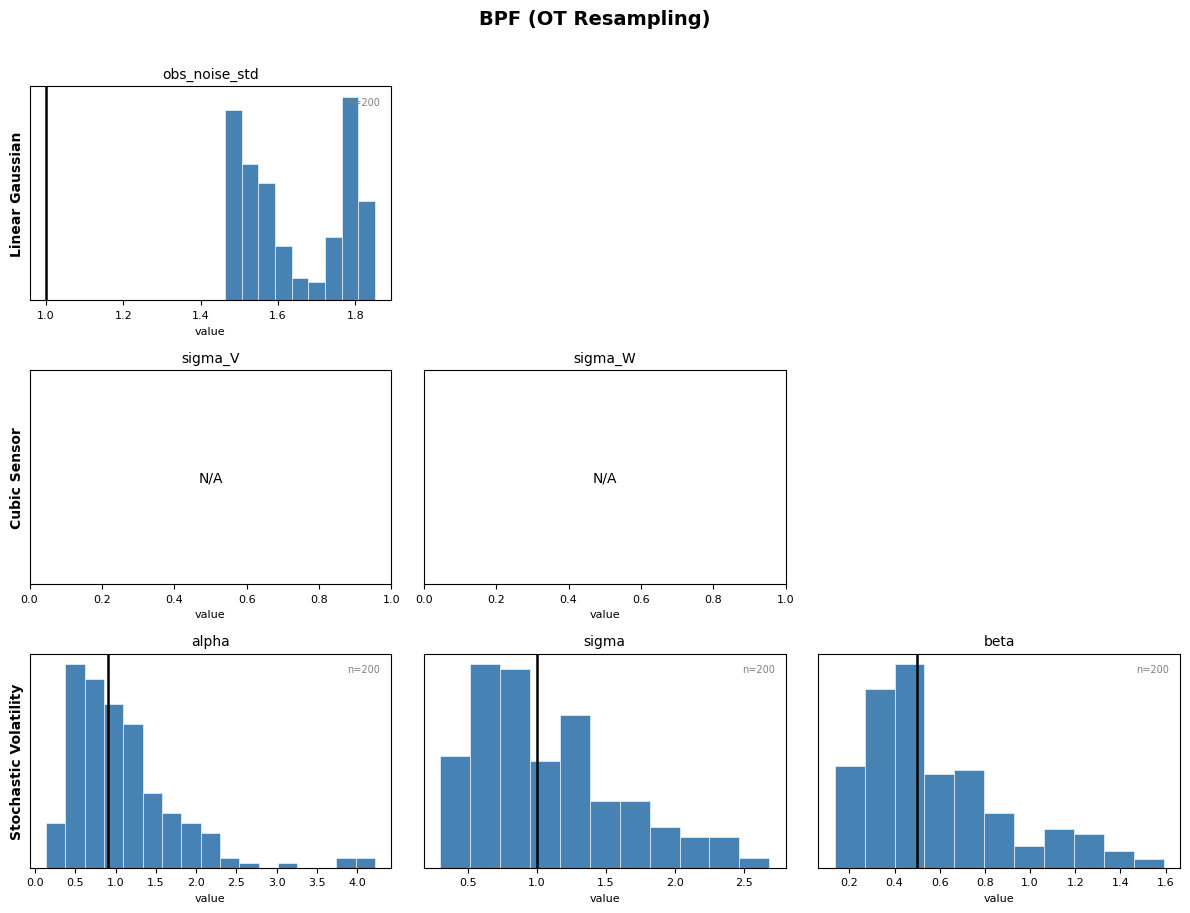

In [66]:
fig_bpf_ot = plot_method_across_models('bpf_ot', 'BPF (OT Resampling)', MODELS_INFO_ALL)

In [67]:
REPORT = Path('../../report')
fig_bpf_soft.savefig(REPORT / 'hmc_bpf_soft.pdf', bbox_inches='tight')
fig_bpf_ot.savefig(REPORT / 'hmc_bpf_ot.pdf', bbox_inches='tight')
print("Saved hmc_bpf_soft.pdf and hmc_bpf_ot.pdf to report/")

Saved hmc_bpf_soft.pdf and hmc_bpf_ot.pdf to report/
